# Построение графиков для статьи

In [1]:
import math
import itertools

import joblib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import qutip
from tqdm import tqdm

In [2]:
import sys
import pathlib

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [3]:
%reload_ext autoreload
%autoreload 2

import bec
import entanglement_propagation
from tools.jupyter import print_model_info
from tools.qutip import TqdmProgressBar
from tools.plot import set_xlabel_as_pi_fraction

In [4]:
N = 30
tspan = np.linspace(0, np.pi, 251)
f_state_span_by_m = dict.fromkeys(range(3, 9))
for m in f_state_span_by_m:
    f_state_span_by_m[m] = qutip.qload(f"../assets/timsway-f_state-m{m}-n{N}")

In [5]:
model = bec.BEC_Qubits.init_default(N, 0)
# h_zz_state_n2_exact_span = [bec.state_under_h_zz_teor_focked(model, t / model.Omega / 4) for t in tqdm(tspan)]
h_nn_state_n2_exact_span = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(bec.state_under_h_na_exact_focked)(model, t)
    for t in tqdm(tspan, ncols=90)
)

100%|███████████████████████████████████████████████████| 251/251 [00:05<00:00, 42.22it/s]


## Энтропия

100%|█████████████████████████████████████████████████| 251/251 [00:00<00:00, 3375.43it/s]


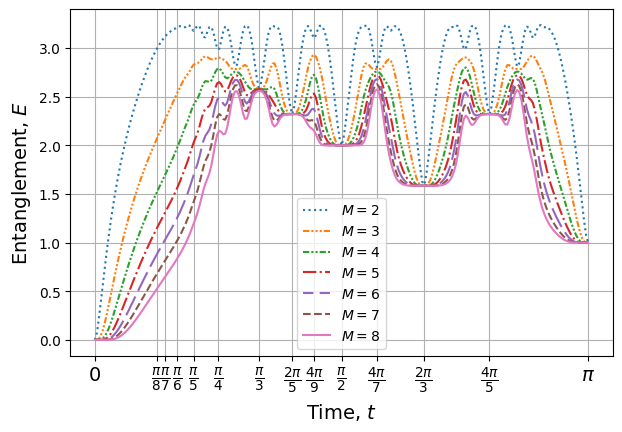

In [6]:
fontsize=14
figsize = (7, 4.5)

fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax.set_title(f"Entanglement of 2-qubit state; N={N}")

linestyles = list(reversed(["-", "--", (5, (10, 3)), "-.", (0, (3, 1, 1, 1, 1, 1)), (0, (3, 1, 1, 1, 1, 1, 1, 1)), ":"]))

h_nn_state_entropy = [qutip.entropy.entropy_vn(qutip.ptrace(s, [0]), base=2) for s in tqdm(h_nn_state_n2_exact_span, ncols=90)]
ax.plot(tspan, h_nn_state_entropy, linestyle=linestyles[0], label=rf"$M=2$")

for ls, (m_, f_state_span) in zip(linestyles[1:], f_state_span_by_m.items()):
    f_state_entropy = [qutip.entropy.entropy_vn(qutip.ptrace(s, [0]), base=2) for s in tqdm(f_state_span, ncols=90)]
    ax.plot(tspan, f_state_entropy, linestyle=ls, label=rf"$M={m_}$")

set_xlabel_as_pi_fraction(ax, fontsize=fontsize)
ax.set_xlabel(r"Time, $t$", fontsize=fontsize)
ax.set_ylabel(r"Entanglement, $E$", fontsize=fontsize)
ax.legend(loc="lower center")
ax.grid()

In [7]:
fig.tight_layout()
fig.savefig(f"../assets/entorpy-n{N}.eps")

## Фиделити

100%|████████████████████████████████████████████████| 251/251 [00:00<00:00, 81521.63it/s]


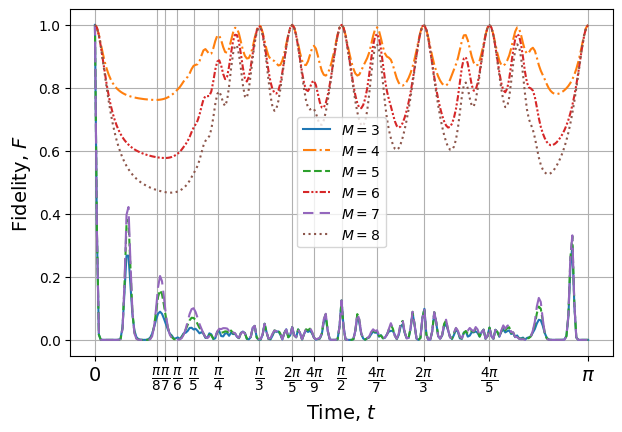

In [27]:
fontsize=14
figsize = (7, 4.5)

fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax.set_title(f"Fidelity between 2-qubit states; N={N}")

linestyles = list(reversed(["-", "--", "-.", ":", (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1))]))
linestyles = ["-", "-.", "--", (0, (3, 1, 1, 1, 1, 1)), (5, (10, 3)), ":" ]

for ls, (m, f_state_span) in zip(linestyles, f_state_span_by_m.items()):
    f_state_fid = [
        qutip.metrics.fidelity(s, s_) ** 2
        for s, s_ in tqdm(zip(
            f_state_span, 
            h_nn_state_n2_exact_span 
            # if m % 2 == 0 else 
            # f_state_span_by_m[3]
        ), total=len(h_nn_state_n2_exact_span), ncols=90)
    ]
    label = rf"$M={m}$" # if m != 3 else rf"$M=2,3$"
    ax.plot(tspan, f_state_fid, label=label, linestyle=ls)

set_xlabel_as_pi_fraction(ax, fontsize=fontsize)
ax.set_xlabel(r"Time, $t$", fontsize=fontsize)
ax.set_ylabel(r"Fidelity, $F$", fontsize=fontsize)
#  ax.legend(loc="lower center")
ax.legend(loc="center")
ax.grid()

In [28]:
fig.tight_layout()
fig.savefig(f"../assets/fidelity-n{N}.eps")

### Фиделити по отношение EPR like состоянию $\frac{1}{\sqrt{C^N_{2N}}} \sum_k C^k_N |k\rangle_1 |k\rangle_2$

In [10]:
def special_reference_state_for_odd_chains(model):
    return sum(
        (
            math.comb(model.n_bosons, k)
            # np.sqrt(math.comb(model.n_bosons, k))
            * qutip.tensor(
                qutip.fock(model.n_bosons + 1, k),
                qutip.fock(model.n_bosons + 1, k)
            )
        )
        for k in range(model.n_bosons + 1)
    ) / math.sqrt(math.comb(2 * model.n_bosons, model.n_bosons))
   


special_reference_state_for_odd_chains_ = special_reference_state_for_odd_chains(model)

In [11]:
qutip.entropy_vn(qutip.ptrace(special_reference_state_for_odd_chains_, [0])) 

1.0182301539513936

100%|███████████████████████████████████████████████| 251/251 [00:00<00:00, 285458.33it/s]


Text(0.5, 1.0, '$F\\left(|\\Psi\\rangle, \\frac{1}{\\sqrt{C^N_{2N}}} \\sum_k C^k_N |k\\rangle_1 |k\\rangle_2\\right)$')

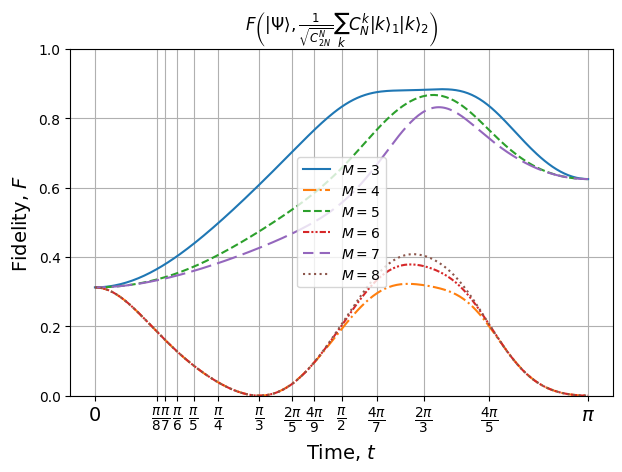

In [12]:
fontsize=14
figsize = (7, 4.5)

fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax.set_title(f"Fidelity between 2-qubit states; N={N}")

linestyles = list(reversed(["-", "--", "-.", ":", (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1))]))
linestyles = ["-", "-.", "--", (0, (3, 1, 1, 1, 1, 1)), (5, (10, 3)), ":" ]

for ls, (m, f_state_span) in zip(linestyles, f_state_span_by_m.items()):
    f_state_fid = [
        qutip.metrics.fidelity(s, special_reference_state_for_odd_chains_) ** 2
        for s in tqdm(f_state_span, total=len(f_state_span), ncols=90)
    ]
    ax.plot(tspan, f_state_fid, label=rf"$M={m}$", linestyle=ls)

ax.set_ylim(0, 1)
set_xlabel_as_pi_fraction(ax, fontsize=fontsize)
ax.set_xlabel(r"Time, $t$", fontsize=fontsize)
ax.set_ylabel(r"Fidelity, $F$", fontsize=fontsize)
ax.legend(loc="center")
ax.grid()
ax.set_title(r"$F\left(|\Psi\rangle, \frac{1}{\sqrt{C^N_{2N}}} \sum_k C^k_N |k\rangle_1 |k\rangle_2\right)$")

### Фиделити по отношению к M=3

100%|███████████████████████████████████████████████| 251/251 [00:00<00:00, 226792.40it/s]


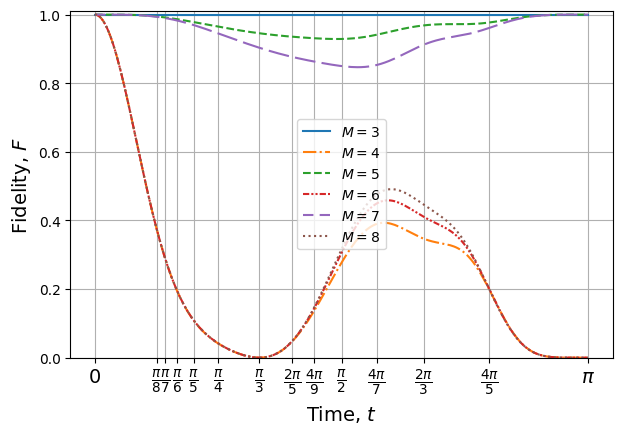

In [13]:
fontsize=14
figsize = (7, 4.5)

fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax.set_title(f"Fidelity between 2-qubit states; N={N}")

linestyles = list(reversed(["-", "--", "-.", ":", (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1))]))
linestyles = ["-", "-.", "--", (0, (3, 1, 1, 1, 1, 1)), (5, (10, 3)), ":" ]

for ls, (m, f_state_span) in zip(linestyles, f_state_span_by_m.items()):
    f_state_fid = [
        qutip.metrics.fidelity(s, s_) ** 2
        for s, s_ in tqdm(zip(f_state_span, f_state_span_by_m[3]), total=len(f_state_span), ncols=90)
    ]
    ax.plot(tspan, f_state_fid, label=rf"$M={m}$", linestyle=ls)

ax.set_ylim(0, 1.01)
set_xlabel_as_pi_fraction(ax, fontsize=fontsize)
ax.set_xlabel(r"Time, $t$", fontsize=fontsize)
ax.set_ylabel(r"Fidelity, $F$", fontsize=fontsize)
ax.legend(loc="center")
ax.grid()
# ax.set_title(r"$F\left(|\Psi\rangle, |\Psi\rangle_{M=3}$")

### Эксперименты на базе M=3

In [27]:
_s = lambda t: sum(
        (
            np.sqrt(math.comb(model.n_bosons, k1))
            * np.sqrt(math.comb(model.n_bosons, k2))
            # * np.exp(1j * k1 * k2 * t)
            # * np.exp(-1j * model.n_bosons * (k1 - k2) * t) 
            * np.cos((k1 - k2) * t / 2)**model.n_bosons
            * qutip.tensor(
                qutip.fock(model.n_bosons + 1, k1),
                qutip.fock(model.n_bosons + 1, k2)
            )
        )
        for k1, k2 in itertools.product(range(model.n_bosons + 1), range(model.n_bosons + 1))
    ) / 2 ** model.n_bosons

In [28]:
_s(np.pi / 2).norm()

0.6123724356957945

In [29]:
_s_span = [(x := _s(t)) / x.norm() for t in tqdm(tspan, ncols=80)]


100%|████████████████████████████████████████| 251/251 [00:00<00:00, 409.06it/s]


In [24]:
_e_span = [qutip.entropy_vn(qutip.ptrace(s, [0]), base=2) for s in tqdm(_s_span, ncols=80)]
_e_span_reduced = [qutip.entropy_vn(qutip.ptrace(s, [0, 1]), base=2) for s in tqdm(state_hnn_m3_reduced_span, ncols=80)]
_e_span_numeric = [qutip.entropy.entropy_vn(qutip.ptrace(s, [0]), base=2) for s in tqdm(f_state_span_by_m[3], ncols=80)]



100%|███████████████████████████████████████| 251/251 [00:00<00:00, 4281.00it/s]

100%|███████████████████████████████████████| 251/251 [00:00<00:00, 5782.99it/s]

100%|███████████████████████████████████████| 251/251 [00:00<00:00, 6835.11it/s]


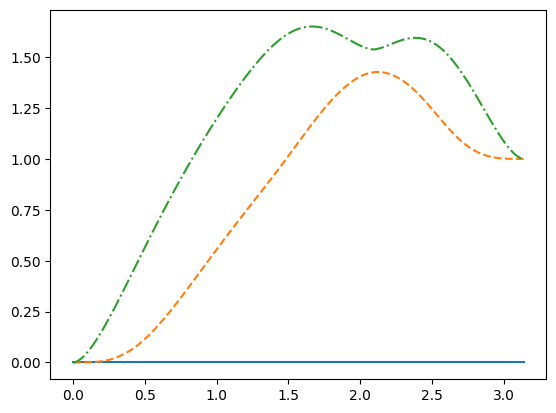

In [25]:
plt.plot(tspan, _e_span)
plt.plot(tspan, _e_span_numeric, "--")
plt.plot(tspan, _e_span_reduced, "-.")


100%|███████████████████████████████████████████████| 251/251 [00:00<00:00, 174213.19it/s]

100%|███████████████████████████████████████████████| 251/251 [00:00<00:00, 159462.33it/s]

100%|███████████████████████████████████████████████| 251/251 [00:00<00:00, 169719.54it/s]

100%|███████████████████████████████████████████████| 251/251 [00:00<00:00, 189620.01it/s]

100%|███████████████████████████████████████████████| 251/251 [00:00<00:00, 183345.58it/s]

100%|████████████████████████████████████████████████| 251/251 [00:00<00:00, 94114.99it/s]


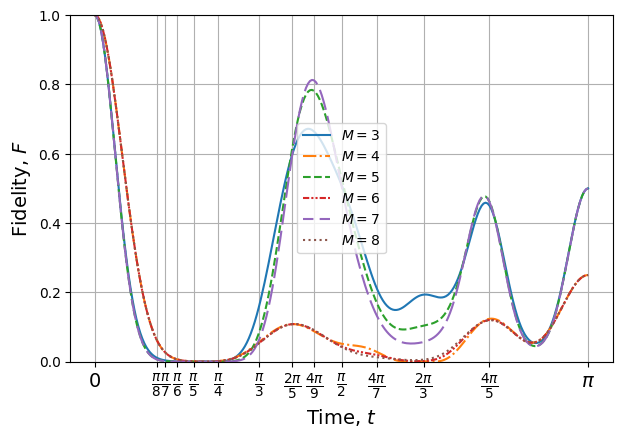

In [26]:
fontsize=14
figsize = (7, 4.5)

fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax.set_title(f"Fidelity between 2-qubit states; N={N}")

linestyles = list(reversed(["-", "--", "-.", ":", (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1))]))
linestyles = ["-", "-.", "--", (0, (3, 1, 1, 1, 1, 1)), (5, (10, 3)), ":" ]

for ls, (m, f_state_span) in zip(linestyles, f_state_span_by_m.items()):
    f_state_fid = [
        qutip.metrics.fidelity(s, s_) ** 2
        for s, s_ in tqdm(zip(f_state_span, _s_span), total=len(f_state_span), ncols=90)
    ]
    ax.plot(tspan, f_state_fid, label=rf"$M={m}$", linestyle=ls)

ax.set_ylim(0, 1)
set_xlabel_as_pi_fraction(ax, fontsize=fontsize)
ax.set_xlabel(r"Time, $t$", fontsize=fontsize)
ax.set_ylabel(r"Fidelity, $F$", fontsize=fontsize)
ax.legend(loc="center")
ax.grid()
# ax.set_title(r"$F\left(|\Psi\rangle, |\Psi\rangle_{M=3}$")

Фиделити по отношении к редуцированному состоянию 

In [13]:
_s_span_numeric = {}
for m in range(3, 6, 2):
    _s_span_numeric[m] = [entanglement_propagation.f_state(t, [N] * (m - 2), m, N, focked=False) for t in tqdm(tspan, ncols=80)]

100%|█████████████████████████████████████████| 251/251 [00:17<00:00, 14.55it/s]


Редуцированное состояние по промежуточным узлам

In [14]:
init_state_m3 = (
    # np.prod([bec.coherent_state_constructor(model, n=m, k=i) for i in range(m)]) # 100x slowly
    math.prod(bec.coherent_state_constructor(model, n=3, k=i) for i in range(3))
    * bec.vacuum_state(model, n=3)
)

%time h_nn_m3 = sum((-1)**(i + 1) * bec.na(model, n=3, k=i) * bec.na(model, n=3, k=i+1) for i in range(2))

state_hnn_m3_span = qutip.sesolve(
    h_nn_m3, init_state_m3, tspan, progress_bar=TqdmProgressBar()
).states

state_hnn_m3_reduced_span = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(lambda x: qutip.ptrace(x, [0, 1, 4, 5]))(s)
    for s in tqdm(state_hnn_m3_span)
)

/Users/kephircheek/venvs/science/emqwuqoc-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 3.16 ms, sys: 205 µs, total: 3.36 ms
Wall time: 4.95 ms


100%|██████████| 251/251 [00:00<00:00, 3005.09it/s]


In [ ]:
state_hnn_m3_reduced_span.dims, 


100%|██████████████████████████████████████████████████| 251/251 [00:00<00:00, 723.54it/s]

100%|██████████████████████████████████████████████████| 251/251 [00:00<00:00, 762.88it/s]


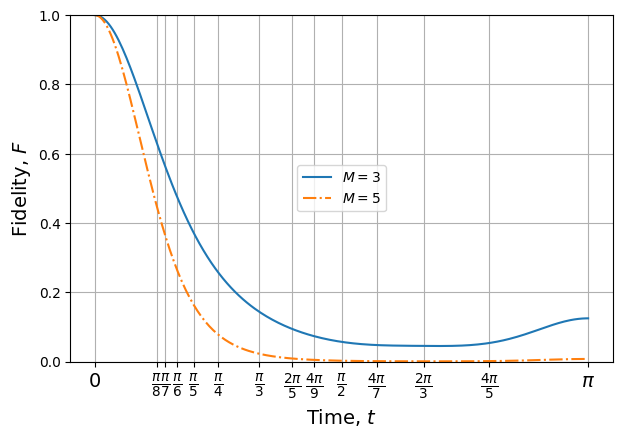

In [20]:
fontsize=14
figsize = (7, 4.5)

fig, ax = plt.subplots(1, 1, figsize=figsize)
# ax.set_title(f"Fidelity between 2-qubit states; N={N}")

linestyles = list(reversed(["-", "--", "-.", ":", (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1))]))
linestyles = ["-", "-.", "--", (0, (3, 1, 1, 1, 1, 1)), (5, (10, 3)), ":" ]

for ls, (m, f_state_span) in zip(linestyles, _s_span_numeric.items()):
    f_state_fid = [
        qutip.metrics.fidelity(s, s_) ** 2
        for s, s_ in tqdm(zip(f_state_span, state_hnn_m3_reduced_span), total=len(f_state_span), ncols=90)
    ]
    ax.plot(tspan, f_state_fid, label=rf"$M={m}$", linestyle=ls)

ax.set_ylim(0, 1)
set_xlabel_as_pi_fraction(ax, fontsize=fontsize)
ax.set_xlabel(r"Time, $t$", fontsize=fontsize)
ax.set_ylabel(r"Fidelity, $F$", fontsize=fontsize)
ax.legend(loc="center")
ax.grid()
# ax.set_title(r"$F\left(|\Psi\rangle, |\Psi\rangle_{M=3}$")

### Фиделити подсиситемы одного спина

100%|██████████████████████████████████████████████████| 251/251 [00:00<00:00, 327.49it/s]


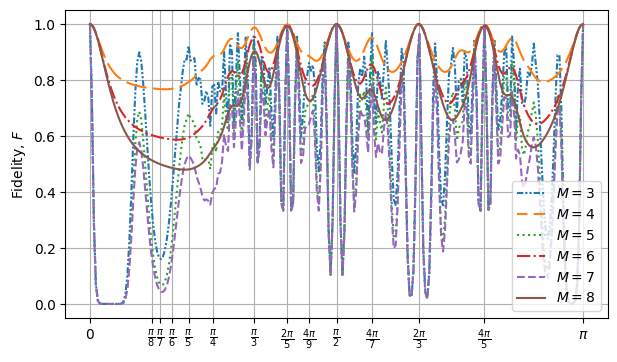

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
# ax.set_title(f"Fidelity between reduced states; N={N}")

linestyles = list(reversed(["-", "--", "-.", ":", (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1))]))

for ls, (m, f_state_span) in zip(linestyles, f_state_span_by_m.items()):
    f_state_reduced_fid = [
        qutip.metrics.fidelity(qutip.ptrace(s, [1]), qutip.ptrace(s_, [1]))**2
        for s, s_ in tqdm(zip(f_state_span, h_nn_state_n2_exact_span), total=len(h_nn_state_n2_exact_span), ncols=90)
    ]
    ax.plot(tspan, f_state_reduced_fid, label=rf"$M={m}$", linestyle=ls)


set_xlabel_as_pi_fraction(ax)
ax.set_ylabel(r"Fidelity, $F$")
ax.legend(loc="lower right")
ax.grid()

In [30]:
fig.tight_layout()
fig.savefig(f"../assets/fidelity-reduced-n{N}.eps")